# Exercice 1 — Mise en place d'un environnement de *Reinforcement Learning*

## Objectif de l'exercice

Avant d'entraîner un agent « intelligent », il faut d'abord **comprendre le terrain de jeu** : l'environnement.
Dans cet exercice, on va :

1. Créer un environnement standard avec **Gymnasium** (`CartPole-v1`).
2. Inspecter ce que l'agent **perçoit** (l'*espace d'observation*) et ce qu'il **peut faire** (l'*espace d'action*).
3. Faire tourner plusieurs parties (**épisodes**) en jouant des actions **complètement au hasard**, pour établir un point de référence.

## L'environnement CartPole (« pendule inversé »)

La scène contient :

- un **chariot** (*cart*) qui peut se déplacer à gauche/droite sur un rail ;
- un **pendule** (*pole*) posé en équilibre sur le chariot, articulé à sa base.

Le pendule tombe naturellement.  
**Le but : garder le pendule debout le plus longtemps possible**, en poussant le chariot à gauche ou à droite.

| Élément | Description |
|---|---|
| **But** | Empêcher le pendule de tomber |
| **Actions** | Pousser le chariot à gauche (`0`) ou à droite (`1`) |
| **Récompense** | `+1` à **chaque** pas de temps où le pendule tient encore |
| **Fin (échec)** | Pendule penché de plus de ~12°, ou chariot sorti de l'écran |
| **Fin (limite)** | 500 pas de temps atteints|

Conséquence directe : **récompense totale = nombre de pas survécus**.   
Donc un agent parfait atteint systématiquement **500**.


## 1. Créer l'environnement et inspecter ses « espaces »

Chaque environnement Gymnasium expose deux objets clés :

- `observation_space` : la **forme et les bornes** de ce que l'agent perçoit ;
- `action_space` : l'ensemble des **actions autorisées**.

Les inspecter est la **toute première chose à faire** face à un nouvel environnement : cela détermine la « taille » des entrées et des sorties de notre futur agent.


In [1]:
import gymnasium as gym

# On instancie l'environnement "CartPole-v1".

env = gym.make("CartPole-v1")

# ESPACE D'OBSERVATION = tout ce que l'agent "perçoit" de l'environnement à chaque instant (l'état du monde tel qu'il est mesuré).
print("=== Espace d'observation ===")
print("Type   :", env.observation_space)         # Box(...) -> espace CONTINU de réels
print("Forme  :", env.observation_space.shape)   # (4,) -> l'état est décrit par 4 nombres
print("Min    :", env.observation_space.low)      # borne basse de chacune des 4 valeurs
print("Max    :", env.observation_space.high)     # borne haute de chacune des 4 valeurs
print("Exemple aléatoire :", env.observation_space.sample())  # un état tiré au hasard

print()

# ESPACE D'ACTION = tout ce que l'agent "peut faire" à chaque étape.
print("=== Espace d'action ===")
print("Type   :", env.action_space)              # Discrete(2) -> 2 actions possibles (0 ou 1)
print("Nb d'actions possibles :", env.action_space.n)
print("Exemple aléatoire :", env.action_space.sample())  # une action au hasard : 0 ou 1

=== Espace d'observation ===
Type   : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Forme  : (4,)
Min    : [-4.8               -inf -0.41887903        -inf]
Max    : [4.8               inf 0.41887903        inf]
Exemple aléatoire : [-0.9083959  -0.04668173 -0.29543155  1.7753083 ]

=== Espace d'action ===
Type   : Discrete(2)
Nb d'actions possibles : 2
Exemple aléatoire : 1


### Comment lire ce résultat ?

**Espace d'observation — `Box([...], [...], (4,), float32)`**

`Box` désigne un espace **continu** : les valeurs sont des nombres réels (`float32`). La forme `(4,)` signifie que chaque observation est un **vecteur de 4 nombres**. Pour CartPole, ces 4 valeurs sont :

| Indice | Grandeur physique | Borne min | Borne max |
|:---:|---|:---:|:---:|
| `observation[0]` | Position du chariot | −4.8 | +4.8 |
| `observation[1]` | Vitesse du chariot | −∞ | +∞ |
| `observation[2]` | Angle du pendule (rad) | −0.418 (~−24°) | +0.418 (~+24°) |
| `observation[3]` | Vitesse angulaire du pendule | −∞ | +∞ |

Les vitesses ne sont pas bornées (`inf`) car elles peuvent, en théorie, devenir arbitrairement grandes.

**Espace d'action — `Discrete(2)`**

`Discrete(2)` = un espace **discret** de 2 actions, codées par des entiers :

- `0` → pousser le chariot vers la **gauche**
- `1` → pousser le chariot vers la **droite**


La méthode `.sample()` (sur l'un ou l'autre espace) tire une valeur au hasard *à l'intérieur* de l'espace. C'est exactement ce qu'on va utiliser pour jouer aléatoirement dans la partie suivante.


## 2. Jouer des épisodes : la boucle d'interaction

On va maintenant faire « vivre » l'environnement. Deux méthodes suffisent :

- **`env.reset()`** → démarre un nouvel épisode et renvoie `(observation, info)`.
- **`env.step(action)`** → applique une action et renvoie **5 valeurs** :
  `observation, reward, terminated, truncated, info`.

### `terminated` vs `truncated` : une distinction importante


- **`terminated = True`** : l'épisode se finit à cause de la **dynamique de la tâche elle-même** (succès ou échec). Ici : le pendule est tombé, ou le chariot est sorti du cadre.
- **`truncated = True`** : l'épisode est coupé par une **contrainte externe**, indépendante de la tâche — typiquement une limite de temps. Ici : on atteint 500 pas.

In [2]:

# Un "épisode" = une partie complète, du départ jusqu'à la chute du pendule ou les 500 pas de temps maximum.
n_episodes = 10

for episode in range(n_episodes):
    observation, info = env.reset() # on réinitialise l'environnement au début de chaque épisode
    terminated = False # on réinitialise les drapeaux de fin d'épisode précédent
    truncated = False # idem
    total_reward = 0.0   # On réinitialise la récompense totale de l'épisode à 0.

    # On boucle TANT QUE l'épisode n'est ni terminé ni tronqué.
    while not (terminated or truncated):

        action = env.action_space.sample() #Action aléatoire : 0 ou 1

        # env.step(action) = coeur de la boucle RL. On applique l'action,
        # l'environnement avance d'un pas et renvoie :
        #   - observation : le nouvel état après l'action
        #   - reward      : la récompense de ce pas (+1 tant que le pendule tient)
        #   - terminated / truncated : les drapeaux de fin (voir ci-avant
        #   - info        : dict d'infos annexes
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward   # on additionne la récompense du pas

    # Fin de l'épisode : récompense totale = nombre de pas "survécus".
    print(f"Épisode {episode + 1:2d} | récompense totale : {total_reward}")

# Bonne pratique : libérer les ressources de l'environnement à la fin.
env.close()

Épisode  1 | récompense totale : 13.0
Épisode  2 | récompense totale : 21.0
Épisode  3 | récompense totale : 25.0
Épisode  4 | récompense totale : 31.0
Épisode  5 | récompense totale : 48.0
Épisode  6 | récompense totale : 52.0
Épisode  7 | récompense totale : 41.0
Épisode  8 | récompense totale : 39.0
Épisode  9 | récompense totale : 11.0
Épisode 10 | récompense totale : 51.0


### Interprétation des résultats

Chaque ligne affiche la **récompense totale** d'un épisode, c'est-à-dire le **nombre de pas** pendant lesquels le pendule est resté debout avant de tomber.

Avec une politique **aléatoire**, on obtient typiquement des scores entre **~10 et ~40** (contre 500 pour un agent parfait). C'est logique : pousser au hasard ne corrige jamais *volontairement* l'inclinaison du pendule. La variabilité d'un épisode à l'autre vient à la fois de l'état de départ (légèrement aléatoire) et des actions tirées au hasard.

**Ce score aléatoire est notre *baseline*** : quand on entraînera un vrai agent (exercices suivants, avec `stable-baselines3`), on voudra voir ce score grimper largement au-dessus de ces valeurs, idéalement jusqu'à 500.

### Ce que j'en retient

- Un environnement Gymnasium s'utilise toujours avec la même interface : `make` → `reset` → boucle de `step` → `close`.
- L'**espace d'observation** décrit ce que l'agent *voit* ; l'**espace d'action** décrit ce qu'il *peut faire*.
- Un **épisode** va d'un `reset` jusqu'à `terminated` **ou** `truncated`.
- La **récompense** guide l'apprentissage ; ici on ne fait que la *mesurer* avec un agent aléatoire.
- **Prochaine étape** : remplacer `env.action_space.sample()` par une vraie **politique apprise**.


## 3. Bonus — Visualiser les épisodes


In [3]:
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")  # rendu sans écran (serveur / headless)
import gymnasium as gym
import numpy as np


def collect_frames(model=None, seed=0, max_steps=500):
    """Joue UN épisode de CartPole et renvoie la liste des images (frames).
    - model=None   -> actions aléatoires (comme dans la partie 2)
    - model=<sb3>  -> actions choisies par un agent entraîné
    """
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    frames = [env.render()]                       # image de l'état initial
    terminated = truncated = False
    steps = 0
    while not (terminated or truncated) and steps < max_steps:
        if model is None:
            action = env.action_space.sample()                    # politique aléatoire
        else:
            action, _ = model.predict(obs, deterministic=True)    # politique apprise
        obs, reward, terminated, truncated, info = env.step(int(action))
        frames.append(env.render())               # on capture l'image après le pas
        steps += 1
    env.close()
    return frames


frames_alea = collect_frames(model=None, seed=42)
print(f"Épisode aléatoire : {len(frames_alea)} images capturées "
      f"(= {len(frames_alea) - 1} pas survécus)")
print(f"Taille d'une image : {frames_alea[0].shape}  (hauteur, largeur, RGB)")

/home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Épisode aléatoire : 12 images capturées (= 11 pas survécus)
Taille d'une image : (400, 600, 3)  (hauteur, largeur, RGB)


GIF sauvegardé : agent_aleatoire.gif


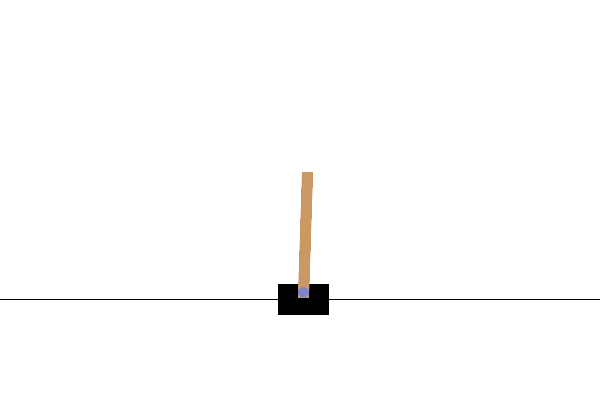

In [4]:
# --- Méthode A : sauvegarder un GIF puis l'afficher ---
import imageio.v2 as imageio
from IPython.display import Image, display

gif_path = "agent_aleatoire.gif"
imageio.mimsave(gif_path, frames_alea, fps=30)   # 30 images par seconde
print(f"GIF sauvegardé : {gif_path}")
display(Image(filename=gif_path))

In [5]:
# --- Méthode B : animation matplotlib directement dans le notebook ---
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(4, 3))
ax.axis("off")
img = ax.imshow(frames_alea[0])


def _update(i):
    img.set_data(frames_alea[i])
    return (img,)


anim = animation.FuncAnimation(
    fig, _update, frames=len(frames_alea), interval=33, blit=True
)
plt.close(fig)          # évite d'afficher une image figée EN PLUS de l'animation
HTML(anim.to_jshtml())

## 4. Entraîner un agent avec Stable-Baselines3

In [6]:
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import torch, time

torch.set_num_threads(1)   # 1 thread = plus rapide ici (cf. explication ci-dessus)

TIMESTEPS = 50_000   # augmente encore pour des scores plus stables (le RL est bruité)
EVAL_FREQ = 2000     # on mesure le score tous les 2000 pas -> pour tracer la courbe


class CourbeApprentissage(BaseCallback):
    """Callback : SB3 l'appelle automatiquement pendant learn(). Tous les
    `eval_freq` pas, on évalue l'agent et on mémorise (pas, score) pour
    pouvoir tracer la courbe d'apprentissage ensuite."""

    def __init__(self, eval_env, eval_freq, n_eval_episodes=10):
        super().__init__()
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.timesteps, self.moyennes, self.ecarts = [], [], []

    def _on_step(self):
        # _on_step() est appelée à CHAQUE pas ; on n'évalue que tous les eval_freq pas.
        if self.n_calls % self.eval_freq == 0:
            m, s = evaluate_policy(self.model, self.eval_env,
                                   n_eval_episodes=self.n_eval_episodes,
                                   deterministic=True)
            self.timesteps.append(self.num_timesteps)
            self.moyennes.append(m)
            self.ecarts.append(s)
        return True   # True = on continue l'entraînement


# On associe un nom à une "fabrique" de modèle (seed fixée = exécution reproductible).
# PPO et A2C : réglages par défaut. DQN : hyperparamètres éprouvés (rl-zoo), sinon il échoue.
constructeurs = {
    "PPO": lambda: PPO("MlpPolicy", "CartPole-v1", verbose=0, seed=0, device="cpu"),
    "A2C": lambda: A2C("MlpPolicy", "CartPole-v1", verbose=0, seed=0, device="cpu"),
    "DQN": lambda: DQN(
        "MlpPolicy", "CartPole-v1", verbose=0, seed=0, device="cpu",
        learning_rate=2.3e-3, batch_size=64, buffer_size=100_000,
        learning_starts=1000, gamma=0.99, target_update_interval=10,
        train_freq=256, gradient_steps=128,
        exploration_fraction=0.16, exploration_final_eps=0.04,
        policy_kwargs=dict(net_arch=[256, 256]),
    ),
}

modeles, resultats, historiques = {}, {}, {}
for nom, construire in constructeurs.items():
    t0 = time.time()
    modele = construire()

    # Le callback évalue périodiquement PENDANT l'entraînement -> courbe d'apprentissage.
    courbe = CourbeApprentissage(Monitor(gym.make("CartPole-v1")), eval_freq=EVAL_FREQ)
    modele.learn(total_timesteps=TIMESTEPS, callback=courbe)   # <-- entraînement ici

    # Évaluation finale "officielle" sur 20 épisodes -> graphe en barres.
    env_eval = Monitor(gym.make("CartPole-v1"))
    moyenne, ecart = evaluate_policy(modele, env_eval, n_eval_episodes=20, deterministic=True)
    env_eval.close()

    modeles[nom] = modele
    resultats[nom] = (moyenne, ecart)
    historiques[nom] = (np.array(courbe.timesteps),
                        np.array(courbe.moyennes),
                        np.array(courbe.ecarts))
    print(f"{nom:4s} | {TIMESTEPS} pas en {time.time() - t0:5.1f}s "
          f"| récompense finale : {moyenne:6.1f} +/- {ecart:.1f}")

PPO  | 50000 pas en  27.6s | récompense finale :  500.0 +/- 0.0
A2C  | 50000 pas en  28.1s | récompense finale :  500.0 +/- 0.0
DQN  | 50000 pas en  39.8s | récompense finale :  500.0 +/- 0.0


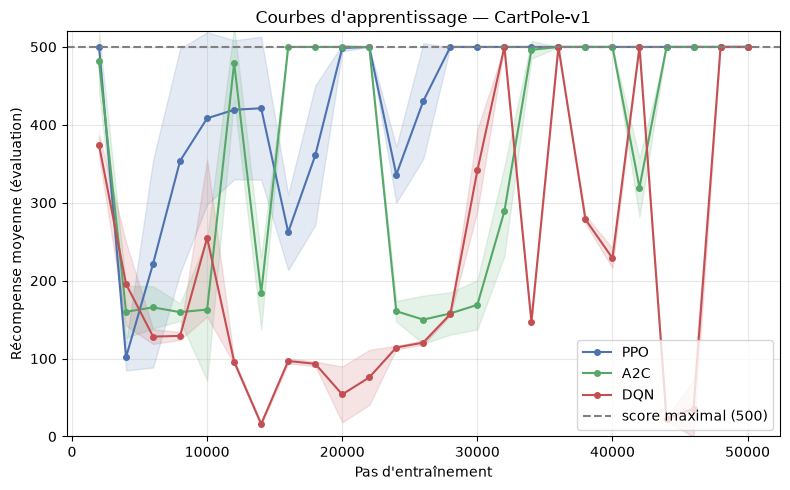

In [7]:
import matplotlib.pyplot as plt

couleurs = {"PPO": "#4C72B0", "A2C": "#55A868", "DQN": "#C44E52"}

fig, ax = plt.subplots(figsize=(8, 5))
for nom, (x, y, e) in historiques.items():
    ax.plot(x, y, marker="o", ms=4, color=couleurs[nom], label=nom)          # la courbe
    ax.fill_between(x, y - e, y + e, color=couleurs[nom], alpha=0.15)          # ± écart-type
ax.axhline(500, ls="--", color="gray", label="score maximal (500)")
ax.set_xlabel("Pas d'entraînement")
ax.set_ylabel("Récompense moyenne (évaluation)")
ax.set_title("Courbes d'apprentissage — CartPole-v1")
ax.set_ylim(0, 520)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

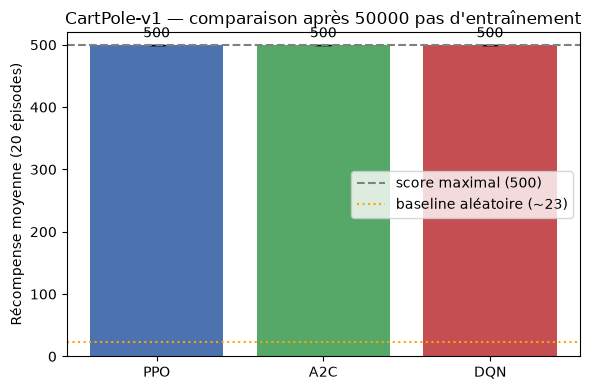

In [8]:
import matplotlib.pyplot as plt

# Baseline aléatoire, recalculée proprement sur 20 épisodes (pour le repère du graphe).
env_r = gym.make("CartPole-v1")
scores_alea = []
for _ in range(20):
    obs, _ = env_r.reset()
    term = trunc = False
    s = 0.0
    while not (term or trunc):
        obs, r, term, trunc, _ = env_r.step(env_r.action_space.sample())
        s += r
    scores_alea.append(s)
env_r.close()
baseline_alea = np.mean(scores_alea)

noms = list(resultats.keys())
moyennes = [resultats[n][0] for n in noms]
ecarts = [resultats[n][1] for n in noms]

fig, ax = plt.subplots(figsize=(6, 4))
barres = ax.bar(noms, moyennes, yerr=ecarts, capsize=6,
                color=["#4C72B0", "#55A868", "#C44E52"])
ax.axhline(500, ls="--", color="gray", label="score maximal (500)")
ax.axhline(baseline_alea, ls=":", color="orange",
           label=f"baseline aléatoire (~{baseline_alea:.0f})")
ax.set_ylabel("Récompense moyenne (20 épisodes)")
ax.set_title(f"CartPole-v1 — comparaison après {TIMESTEPS} pas d'entraînement")
ax.set_ylim(0, 520)
ax.legend()
ax.bar_label(barres, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

## 5. Voir l'agent entraîné en action

Meilleur algo : PPO (récompense 500)
Aléatoire : 11 pas survécus   |   PPO entraîné : 500 pas survécus


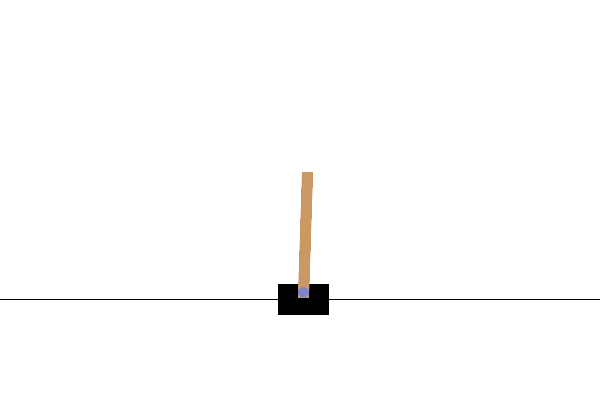

In [9]:
meilleur = max(resultats, key=lambda n: resultats[n][0])
print(f"Meilleur algo : {meilleur} (récompense {resultats[meilleur][0]:.0f})")

frames_entraine = collect_frames(model=modeles[meilleur], seed=42)
imageio.mimsave("agent_entraine.gif", frames_entraine, fps=30)

print(f"Aléatoire : {len(frames_alea) - 1} pas survécus   |   "
      f"{meilleur} entraîné : {len(frames_entraine) - 1} pas survécus")
display(Image(filename="agent_entraine.gif"))